# 01 欧式期权：从定价到 Greeks

这个例子用一个欧式看涨期权走一遍 `dal_jax` 的基本用法：

1. 用一个单路径 payoff 函数定义产品（`PathProduct`），选择模型（`BlackScholes`）；
2. 用 `MonteCarloEngine.value` 得到 DAL 风格的结果 `{"PV", "d_<label>"}`；
3. 和 Black-Scholes 闭式解、以及 DAL（dal-python）在相同 Sobol 点上的结果对照；
4. 比较 Sobol 与伪随机数的收敛速度。

In [1]:
import os

import dal_jax as dj

# Split the CPU into virtual devices so Monte Carlo blocks run in parallel.
# JAX only accepts this before its first operation, so keep it at the top.
dj.config.configure(num_cpu_devices=min(8, os.cpu_count() or 1))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from nbtools import AQUA, BLUE, MUTED, ORANGE, apply_style, label_end, show_table

try:
    import dal  # dal-python, only used for side-by-side comparisons
except ImportError:
    dal = None

apply_style()
print(f"jax {jax.__version__}: {len(jax.devices())} x {jax.devices()[0].platform} device(s); dal-python: {dal is not None}")

starting DAL with: 32 threads.
use AAD framework: AADET
starting initialization global data ...
finished initialization all the global information.
jax 0.11.2: 8 x cpu device(s); dal-python: True


## 1. 产品与模型

payoff 只描述**一条路径**，引擎会在路径维度上自动 `vmap`。它接收三个参数：

- `params`：参数 pytree，`params["model"]` 是模型参数，`params["script"]` 是产品常量（这里是 `STRIKE`），**所有叶子都可以求导**；
- `scenario`：模型生成的路径，`scenario.spot[i]` 和 `scenario.numeraire[i]` 是第 i 个日期上的现价和计价单位；
- `ctx`：求值模式（exact 或 fuzzy），这个 payoff 没有不连续点，用不到。

返回值要除以计价单位，相当于 DAL 脚本里的 `PAYS`。

In [2]:
SPOT, VOL, RATE, DIV = 100.0, 0.15, 0.05, 0.03
STRIKE, T = 120.0, 3.0


def call(params, scenario, ctx):
    payoff = jnp.maximum(scenario.spot[-1] - params["script"]["STRIKE"], 0.0)
    return payoff / scenario.numeraire[-1]


product = dj.PathProduct(timeline=(T,), payoff=call, payoff_names=("call",), script_params={"STRIKE": STRIKE})
model = dj.BlackScholes(spot=SPOT, vol=VOL, rate=RATE, div=DIV)

## 2. 只算价格，或价格加 Greeks

`enable_aad=True` 与 DAL 的同名开关含义一致：价格和全部 Greeks 都由 `jax.value_and_grad` 一次算出。
Greeks 的名字是 `d_<label>`，顺序为模型参数在前、产品常量在后。

In [3]:
N_PATHS = 2**20

price_engine = dj.MonteCarloEngine(product, model)
greeks_engine = dj.MonteCarloEngine(product, model, dj.MonteCarloSettings(enable_aad=True))

price = price_engine.value(N_PATHS)
greeks = greeks_engine.value(N_PATHS)
show_table(["结果", "值"], [[k, v] for k, v in greeks.items()], fmt="{:.10f}")

| 结果 | 值 |
|:---|---:|
| PV | 5.2017688332 |
| d_spot | 0.3350314494 |
| d_vol | 59.5850327569 |
| d_rate | 84.9041283109 |
| d_div | -100.5094348105 |
| d_STRIKE | -0.2358448009 |

## 3. 与 Black-Scholes 闭式解对照

闭式解同样用 JAX 写，于是它的 Greeks 也可以直接用 `jax.grad` 求出来。

In [4]:
from jax.scipy.stats import norm


def bs_call(spot, vol, rate, div, strike, t=T):
    d1 = (jnp.log(spot / strike) + (rate - div + 0.5 * vol**2) * t) / (vol * jnp.sqrt(t))
    d2 = d1 - vol * jnp.sqrt(t)
    return spot * jnp.exp(-div * t) * norm.cdf(d1) - strike * jnp.exp(-rate * t) * norm.cdf(d2)


args = (SPOT, VOL, RATE, DIV, STRIKE)
exact = {"PV": float(bs_call(*args))}
for name, g in zip(["d_spot", "d_vol", "d_rate", "d_div", "d_STRIKE"], jax.grad(bs_call, argnums=range(5))(*args)):
    exact[name] = float(g)

show_table(
    ["结果", "Monte Carlo（2²⁰ Sobol）", "闭式解", "相对差异"],
    [[k, greeks[k], exact[k], f"{abs(greeks[k] / exact[k] - 1):.1e}"] for k in exact],
    fmt="{:.6f}",
)

| 结果 | Monte Carlo（2²⁰ Sobol） | 闭式解 | 相对差异 |
|:---|---:|---:|---:|
| PV | 5.201769 | 5.201879 | 2.1e-05 |
| d_spot | 0.335031 | 0.335033 | 5.7e-06 |
| d_vol | 59.585033 | 59.586395 | 2.3e-05 |
| d_rate | 84.904128 | 84.904370 | 2.9e-06 |
| d_div | -100.509435 | -100.510007 | 5.7e-06 |
| d_STRIKE | -0.235845 | -0.235845 | 2.9e-06 |

## 4. 与 DAL 逐路径对照（需要 dal-python）

`dal_jax` 逐运算移植了 DAL 的 Sobol 方向数、`InverseNCDF` 和 BS 路径生成，所以在相同路径数下，两边处理的是**同一批路径**。
差异只来自浮点运算的末位，远小于 issue #1 的验收标准（PV ≤ 1e-10，Greeks ≤ 1e-8）。

In [5]:
if dal is None:
    print("dal-python 未安装，跳过对照。")
else:
    today = dal.Date_(2022, 9, 15)
    dal.EvaluationDate_Set(today)
    dal_product = dal.Product_New(["STRIKE", today.AddDays(int(365 * T))], [f"{STRIKE}", "call pays MAX(spot() - STRIKE, 0.0)"])
    dal_model = dal.BSModelData_New(SPOT, VOL, RATE, DIV)
    theirs = dict(dal.MonteCarlo_Value(dal_product, dal_model, N_PATHS, "sobol", False, True))
    show_table(
        ["结果", "dal_jax", "DAL", "相对差异"],
        [[k, f"{greeks[k]:.15f}", f"{theirs[k]:.15f}", f"{abs(greeks[k] / theirs[k] - 1):.1e}"] for k in greeks],
    )

| 结果 | dal_jax | DAL | 相对差异 |
|:---|---:|---:|---:|
| PV | 5.201768833210827 | 5.201768833210825 | 4.4e-16 |
| d_spot | 0.335031449368459 | 0.335031449368459 | 0.0e+00 |
| d_vol | 59.585032756911907 | 59.585032756911922 | 2.2e-16 |
| d_rate | 84.904128310905151 | 84.904128310905165 | 2.2e-16 |
| d_div | -100.509434810537641 | -100.509434810537599 | 4.4e-16 |
| d_STRIKE | -0.235844800863625 | -0.235844800863634 | 3.7e-14 |

## 5. 收敛速度：Sobol 与伪随机数

`rsg="mrg32"` 使用 `jax.random`，每个块的 key 由 `fold_in(seed, block_id)` 派生，结果与设备数无关。
Sobol 的误差下降速度接近 1/N，伪随机数是 1/√N。

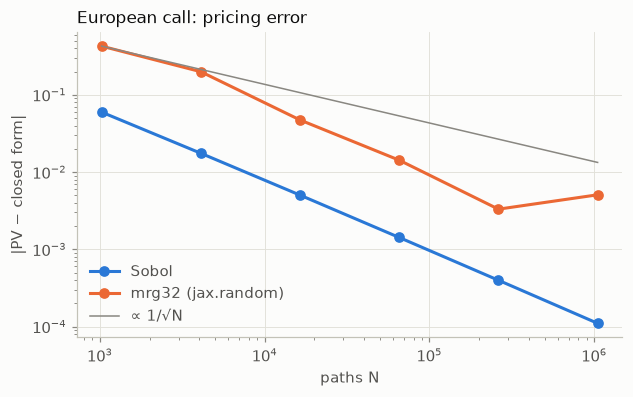

| N | Sobol 误差 | mrg32 误差 |
|:---|---:|---:|
| 2^10 | 5.97e-02 | 4.27e-01 |
| 2^12 | 1.75e-02 | 1.99e-01 |
| 2^14 | 5.03e-03 | 4.72e-02 |
| 2^16 | 1.42e-03 | 1.42e-02 |
| 2^18 | 3.98e-04 | 3.31e-03 |
| 2^20 | 1.10e-04 | 5.08e-03 |

In [6]:
path_counts = [2**k for k in range(10, 21, 2)]
errors = {}
for rsg in ("sobol", "mrg32"):
    engine = dj.MonteCarloEngine(product, model, dj.MonteCarloSettings(rsg=rsg))
    errors[rsg] = [abs(engine.value(n)["PV"] - exact["PV"]) for n in path_counts]

fig, ax = plt.subplots()
ax.loglog(path_counts, errors["sobol"], marker="o", color=BLUE, label="Sobol")
ax.loglog(path_counts, errors["mrg32"], marker="o", color=ORANGE, label="mrg32 (jax.random)")
reference = [errors["mrg32"][0] * (path_counts[0] / n) ** 0.5 for n in path_counts]
ax.loglog(path_counts, reference, color=MUTED, linewidth=1, label="∝ 1/√N")
ax.set_xlabel("paths N")
ax.set_ylabel("|PV − closed form|")
ax.set_title("European call: pricing error")
ax.legend(loc="lower left")
plt.show()

show_table(
    ["N", "Sobol 误差", "mrg32 误差"],
    [[f"2^{n.bit_length() - 1}", s, p] for n, s, p in zip(path_counts, errors["sobol"], errors["mrg32"])],
    fmt="{:.2e}",
)

## 6. 运行时间

第一次调用包含 XLA 编译，之后同样的路径数直接复用编译结果。默认的块大小是 8192 条路径（与 DAL 一致），
块在设备之间用 `shard_map` 分配，所以在 setup 里拆出的虚拟 CPU 设备越多，CPU 利用率越高（见 notebook 04）。

In [7]:
%timeit -r 5 -n 1 price_engine.value(N_PATHS)
%timeit -r 5 -n 1 greeks_engine.value(N_PATHS)

5.19 ms ± 537 μs per loop (mean ± std. dev. of 5 runs, 1 loop each)
10.9 ms ± 2.1 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


## 小结

- 产品是一个单路径函数，常量放进 `script_params` 后会自动出现在 Greeks 里；
- `value()` 是 DAL 风格的接口；需要更多控制时，`engine.pricer(n)` 返回一个可以被 `jit`/`grad`/`vmap` 组合的纯函数（notebook 03）；
- 有障碍、数字期权这类不连续 payoff 时，求导需要 fuzzy 平滑（notebook 02）。